# Stage 4 — The Graph Neural Operator (GNO)

FNO's spectral trick requires the kernel to be **translation-invariant**, $\kappa(x,y)=\kappa(x-y)$, and relies on the FFT, which needs a regular grid. GNO (Section 4.1 of the paper) instead approximates the general integral kernel operator
$$(\mathcal{K}v)(x) = \int_D \kappa(x,y)\,v(y)\,dy$$
directly, so it can (in principle) work on irregular point clouds/meshes, at the cost of needing an explicit approximation scheme to avoid the $O(J^2)$ cost of a naive discretization. Two ideas combine to fix this:

**1. Truncation** (Eq. 16): only integrate over a local neighborhood $s(x) = B(x, r)$ (points within radius $r$ of $x$):
$$(\mathcal{K}v)(x) \approx \int_{B(x,r)} \kappa(x,y)\,v(y)\,dy$$
This turns the dense integral into a sparse sum and, just like a CNN's receptive field, builds in a useful locality bias for problems with local physical interactions.

**2. Nyström approximation**: instead of summing over *every* grid point, sum only over a small, randomly-subsampled subset of $J' \ll J$ "key" points (paper Eq. 15, viewing this as a low-rank approximation of the kernel matrix). This is the classic Nyström method from kernel methods / spectral clustering, applied here to make the sum tractable.

Combining both, the update at each layer (paper, equation following Eq. 16) is a **message-passing** operation:
$$u(x_j) = \frac{1}{|N(x_j)|} \sum_{y \in N(x_j)} \kappa(x_j, y)\, v(y)$$
where $N(x_j) = B(x_j, r) \cap \{\text{key points}\}$, and $\kappa(x,y)$ is *learned*: a small MLP maps the edge features $(x, y)$ to a $d_{v_{out}} \times d_{v_{in}}$ matrix (`neural_operators/layers/kernel_nn.py`), so a different linear map is applied along every edge — far more expressive than a single shared weight matrix.

This is implemented in `neural_operators/models/gno.py`. Because the graph is built directly from point coordinates (not FFT / grid-shape requirements), GNO could in principle run on an unstructured mesh; here we build the graph from our regular grid's coordinates for a direct, apples-to-apples comparison with FNO.

In [1]:
import sys, os, json, time
sys.path.append(os.path.abspath(".."))

import torch
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader

from neural_operators.models.gno import GNO2d
from neural_operators.utils import train_model, count_params, measure_inference_time, RelativeL2Loss

torch.manual_seed(0)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

device: cuda


In [2]:
cache = torch.load("../data_cache/navier_stokes_64.pt")
a_data, u_data = cache["a"], cache["u"]
n_train, n_test = cache["n_train"], cache["n_test"]

a_mean, a_std = a_data[:n_train].mean(), a_data[:n_train].std()
u_mean, u_std = u_data[:n_train].mean(), u_data[:n_train].std()
a_norm = (a_data - a_mean) / a_std
u_norm = (u_data - u_mean) / u_std

train_ds = TensorDataset(a_norm[:n_train], u_norm[:n_train])
test_ds = TensorDataset(a_norm[n_train:], u_norm[n_train:])
train_loader = DataLoader(train_ds, batch_size=20, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=20, shuffle=False)

In [3]:
model = GNO2d(in_channels=3, out_channels=1, width=24, n_layers=4, radius=0.08, n_subsample=512)
print("trainable parameters:", count_params(model))

# trigger graph construction once up front so its (one-time) cost isn't counted in epoch 0's time
with torch.no_grad():
    model.to(device)(torch.zeros(1, 64, 64, device=device))

history = train_model(model, train_loader, test_loader, epochs=80, lr=2e-3, device=device, verbose_every=10)

trainable parameters: 176001


epoch    0 | train rel-L2 0.7129 | test rel-L2 0.3775 | 1.4s


epoch   10 | train rel-L2 0.1365 | test rel-L2 0.1274 | 12.3s


epoch   20 | train rel-L2 0.0967 | test rel-L2 0.0986 | 23.3s


epoch   30 | train rel-L2 0.0899 | test rel-L2 0.0942 | 34.2s


epoch   40 | train rel-L2 0.0839 | test rel-L2 0.0860 | 45.2s


epoch   50 | train rel-L2 0.0813 | test rel-L2 0.0840 | 56.3s


epoch   60 | train rel-L2 0.0794 | test rel-L2 0.0823 | 67.3s


epoch   70 | train rel-L2 0.0783 | test rel-L2 0.0815 | 78.4s


epoch   79 | train rel-L2 0.0782 | test rel-L2 0.0813 | 88.4s


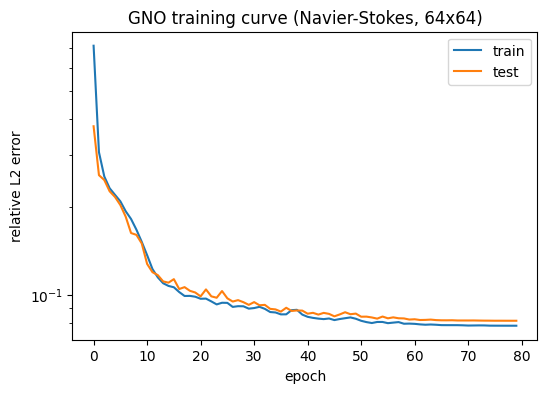

final test relative L2 error: 0.0813


In [4]:
plt.figure(figsize=(6, 4))
plt.plot(history["train_loss"], label="train")
plt.plot(history["test_loss"], label="test")
plt.xlabel("epoch")
plt.ylabel("relative L2 error")
plt.yscale("log")
plt.legend()
plt.title("GNO training curve (Navier-Stokes, 64x64)")
plt.show()
print(f"final test relative L2 error: {history['test_loss'][-1]:.4f}")

## Qualitative check

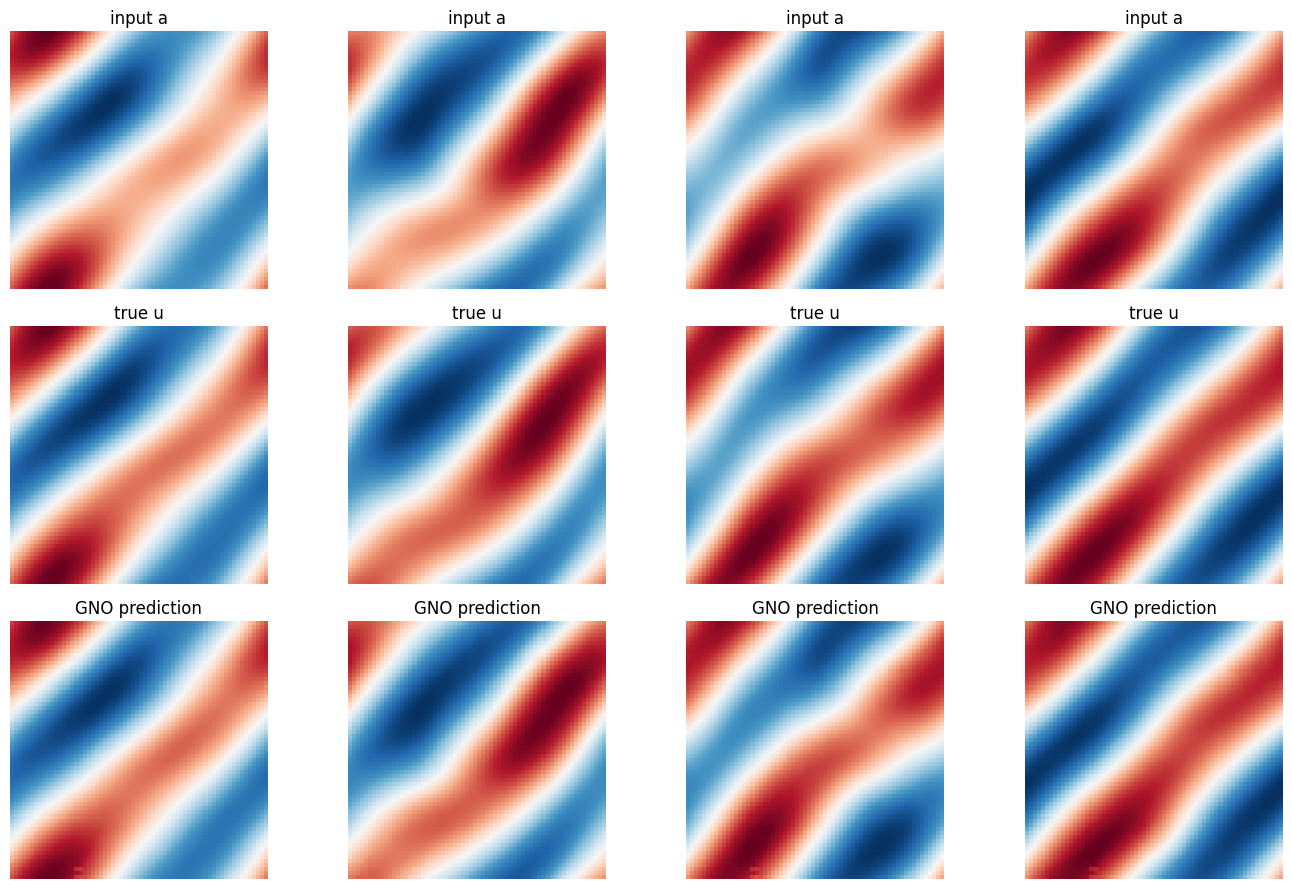

In [5]:
model.eval()
with torch.no_grad():
    x_sample, y_sample = next(iter(test_loader))
    pred = model(x_sample.to(device)).cpu()

fig, axes = plt.subplots(3, 4, figsize=(14, 9))
for i in range(4):
    axes[0, i].imshow(x_sample[i] * a_std + a_mean, cmap="RdBu_r"); axes[0, i].set_title("input a"); axes[0, i].axis("off")
    axes[1, i].imshow(y_sample[i] * u_std + u_mean, cmap="RdBu_r"); axes[1, i].set_title("true u"); axes[1, i].axis("off")
    axes[2, i].imshow(pred[i] * u_std + u_mean, cmap="RdBu_r"); axes[2, i].set_title("GNO prediction"); axes[2, i].axis("off")
plt.tight_layout()
plt.show()

## Discretization invariance and cost comparison

GNO's graph is rebuilt (and cached) for whatever resolution it is called with, so, like FNO, the same trained weights can be evaluated on a different grid. Because the Nyström key-point count is fixed at `n_subsample` regardless of resolution, GNO's per-point cost stays roughly constant as resolution grows (unlike a naive $O(J^2)$ kernel sum) — though building/caching a new graph the first time a resolution is seen does take a moment.

resolution   32x32   -> relative L2 error: 0.0908


resolution   64x64   -> relative L2 error: 0.0826


resolution   96x96   -> relative L2 error: 0.0847


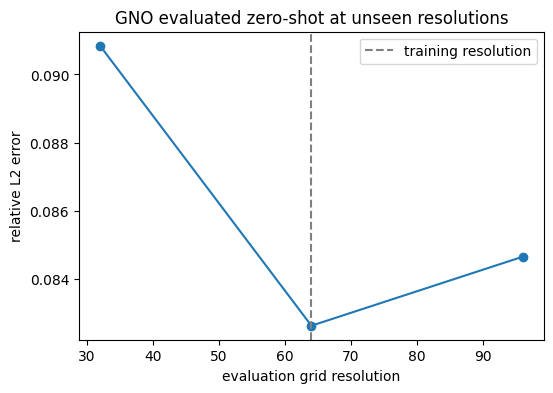

In [6]:
from neural_operators.data.grf import GaussianRF2d
from neural_operators.data.navier_stokes_2d import solve_navier_stokes_2d, default_forcing

def make_hr_test_set(n_hr, n_samples=20, seed=123):
    torch.manual_seed(seed)
    grf_hr = GaussianRF2d(n_hr, alpha=2.5, tau=7.0, device=device)
    f_hr = default_forcing(n_hr, device=device)
    w0 = grf_hr.sample(n_samples)
    burnin, _ = solve_navier_stokes_2d(w0, f_hr, visc=1e-3, T=4.5, delta_t=1e-3, record_steps=1)
    a = burnin[..., -1]
    traj, _ = solve_navier_stokes_2d(a, f_hr, visc=1e-3, T=2.0, delta_t=1e-3, record_steps=1)
    return a.cpu(), traj[..., -1].cpu()

resolutions = [32, 64, 96]
errors = []
loss_fn = RelativeL2Loss()
for res in resolutions:
    a_res, u_res = make_hr_test_set(res, n_samples=20)
    a_res_n = (a_res - a_mean) / a_std
    u_res_n = (u_res - u_mean) / u_std
    with torch.no_grad():
        pred = model(a_res_n.to(device))
    err = loss_fn(pred.cpu(), u_res_n).item()
    errors.append(err)
    print(f"resolution {res:>4d}x{res:<4d} -> relative L2 error: {err:.4f}")

plt.figure(figsize=(6, 4))
plt.plot(resolutions, errors, marker="o")
plt.axvline(64, color="gray", linestyle="--", label="training resolution")
plt.xlabel("evaluation grid resolution")
plt.ylabel("relative L2 error")
plt.title("GNO evaluated zero-shot at unseen resolutions")
plt.legend()
plt.show()

In [7]:
x_batch = a_norm[:20]
gno_time = measure_inference_time(model, x_batch, device=device)
print(f"GNO inference time per sample: {gno_time*1000:.3f} ms")

os.makedirs("../results", exist_ok=True)
torch.save(model.state_dict(), "../results/gno_navier_stokes.pt")
with open("../results/gno_summary.json", "w") as fp:
    json.dump({
        "params": count_params(model),
        "final_test_rel_l2": history["test_loss"][-1],
        "inference_time_s": gno_time,
        "discretization_invariance": dict(zip(resolutions, errors)),
    }, fp, indent=2)
print("saved model + summary to ../results/")

GNO inference time per sample: 30.830 ms
saved model + summary to ../results/


## Next step

`04_lno.ipynb` implements the **Low-rank Neural Operator**, which factorizes $\kappa(x,y) \approx \sum_{r=1}^R \phi_r(x)\psi_r(y)$ to reduce the cost of applying the integral operator from $O(J^2)$ to $O(RJ)$, without needing truncation or subsampling at all.